[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Mate_MercadosFinancieros/blob/main/Semana9_Empirical_Mode_Decomposition.ipynb)

# Predicción en series de tiempo utilizando Empirical Mode Decomposition.

# Resumen:#

Una serie de tiempo se descompone en "Intrinsic Mode Functions" (IMFs). Despues estas IMFs se utilizan como características para una red neuronal convolucional, que puede aprender la descomposición y tal vez con esto mejorar la predicción. Nota: El modelo es aditivo, supone que la serie de tiempo se descompone como la suma de diversas series de tiempo.

En este caso, tomaremos los 10 pasos anteriores para hacer una prediccion del siguiente valor de la serie de tiempo.

# Datos
Tomamos los valores de los bonos del tesoro de EUA a 13 semanas, utilizando yahoo finance.

# Arquitectura y proceso



1.   4 Capas convolucionales, todas con la misma estructura.
2.   Concatenamos estas cuatro capas.
3.   Pasamos la convolucion a que nos den 11 salidas (1 por cada IMF)
4.   Sumamos la predicción de estas IMF para reconstruir la señal, para que sea la predicción del siguiente paso.
5.   Evaluación del modelo



In [ ]:
!pip install pyhht
!pip install PeakUtils
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#import pandas_datareader.data as web
from pandas import Series
from pandas import DataFrame
from pandas import concat
import matplotlib.pyplot as plt
import os
from scipy.integrate import odeint
#keras
from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras.callbacks import *
from keras import backend as K
#from keras.engine.topology import Layer
from keras.layers import Layer
import peakutils
#!pip install pyramid-arima
#from pyramid.arima import auto_arima

In [ ]:
!cat /usr/local/lib/python3.10/dist-packages/pyhht/utils.py

#! /usr/bin/env python
# -*- coding: utf-8 -*-
# vim:fenc=utf-8
#
# Copyright © 2015 jaidev <jaidev@newton>
#
# Distributed under terms of the MIT license.

"""
Utility functions used to inspect EMD functionality.
"""

import numpy as np
from scipy.signal import argrelmax, argrelmin
from scipy import interpolate#, angle
from numpy import angle


def inst_freq(x, t=None, L=1):
    """
    Compute the instantaneous frequency of an analytic signal at specific
    time instants using the trapezoidal integration rule.

    :param x: The input analytic signal
    :param t: The time instants at which to calculate the instantaneous frequencies.
    :param L: Non default values are currently not supported.
        If L is 1, the normalized instantaneous frequency is computed. If L > 1,
        the maximum likelihood estimate of the instantaneous frequency of the
        deterministic part of the signal.
    :type x: numpy.ndarray
    :type t: numpy.ndarray
    :type L: int
    :return: instanta

In [ ]:
%%writefile /usr/local/lib/python3.10/dist-packages/pyhht/utils.py
#! /usr/bin/env python
# -*- coding: utf-8 -*-
# vim:fenc=utf-8
#
# Copyright © 2015 jaidev <jaidev@newton>
#
# Distributed under terms of the MIT license.

"""
Utility functions used to inspect EMD functionality.
"""

import numpy as np
from scipy.signal import argrelmax, argrelmin
from scipy import interpolate#, angle
from numpy import angle


def inst_freq(x, t=None, L=1):
    """
    Compute the instantaneous frequency of an analytic signal at specific
    time instants using the trapezoidal integration rule.

    :param x: The input analytic signal
    :param t: The time instants at which to calculate the instantaneous frequencies.
    :param L: Non default values are currently not supported.
        If L is 1, the normalized instantaneous frequency is computed. If L > 1,
        the maximum likelihood estimate of the instantaneous frequency of the
        deterministic part of the signal.
    :type x: numpy.ndarray
    :type t: numpy.ndarray
    :type L: int
    :return: instantaneous frequencies of the input signal.
    :rtype: numpy.ndarray
    :Example:
    >>> from tftb.generators import fmsin
    >>> import matplotlib.pyplot as plt
    >>> x = fmsin(70, 0.05, 0.35, 25)[0]
    >>> instf, timestamps = inst_freq(x)
    >>> plt.plot(timestamps, instf) #doctest: +SKIP

    .. plot:: docstring_plots/utils/inst_freq.py
    """
    if x.ndim != 1:
        if 1 not in x.shape:
            raise TypeError("Input should be a one dimensional array.")
        else:
            x = x.ravel()
    if t is not None:
        if t.ndim != 1:
            if 1 not in t.shape:
                raise TypeError("Time instants should be a one dimensional "
                                "array.")
            else:
                t = t.ravel()
    else:
        t = np.arange(2, len(x))

    fnorm = 0.5 * (angle(-x[t] * np.conj(x[t - 2])) + np.pi) / (2 * np.pi)
    return fnorm, t


def boundary_conditions(signal, time_samples, z=None, nbsym=2):
    """
    Extend the signal beyond it's bounds w.r.t mirror symmetry.

    :param x: Signal to be mirrored.
    :param t: Timestamps of the signal
    :param z: Signal on whose extrema the interpolation is evaluated. (By \
        default this is just ``x``)
    :param nbsym: Number of points added to each end of the signal.
    :type x: array-like
    :type t: array-like
    :type z: array-like
    :type nbsym: int
    :return: timestamps and values of extended extrema, ordered as (minima \
        timestamps, maxima timestamps, minima values, maxima values.)
    :rtype: tuple
    :Example:
    >>> from __future__ import print_function
    >>> import numpy as np
    >>> signal = np.array([-1, 1, -1, 1, -1])
    >>> print(boundary_conditions(signal, np.arange(5)))
    (array([-2,  2,  6]), array([-3, -1,  1,  3,  5,  7]), array([-1, -1, -1]), array([1, 1, 1, 1, 1, 1]))
    """
    tmax = argrelmax(signal)[0]
    maxima = signal[tmax]
    tmin = argrelmin(signal)[0]
    minima = signal[tmin]

    if tmin.shape[0] + tmax.shape[0] < 3:
        raise ValueError("Not enough extrema.")

    loffset_max = time_samples[tmax[:nbsym]] - time_samples[0]
    roffset_max = time_samples[-1] - time_samples[tmax[-nbsym:]]
    new_tmax = np.r_[time_samples[0] - loffset_max[::-1], time_samples[tmax], roffset_max[::-1] + time_samples[-1]]
    new_vmax = np.r_[maxima[:nbsym][::-1], maxima, maxima[-nbsym:][::-1]]

    loffset_min = time_samples[tmin[:nbsym]] - time_samples[0]
    roffset_min = time_samples[-1] - time_samples[tmin[-nbsym:]]

    new_tmin = np.r_[time_samples[0] - loffset_min[::-1], time_samples[tmin], roffset_min[::-1] + time_samples[-1]]
    new_vmin = np.r_[minima[:nbsym][::-1], minima, minima[-nbsym:][::-1]]
    return new_tmin, new_tmax, new_vmin, new_vmax


def get_envelops(x, t=None):
    """ Find the upper and lower envelopes of the array `x`.
    :Example:
    >>> import numpy as np
    >>> x = np.random.rand(100,)
    >>> upper, lower = get_envelops(x)
    """
    if t is None:
        t = np.arange(x.shape[0])
    maxima = argrelmax(x)[0]
    minima = argrelmin(x)[0]

    # consider the start and end to be extrema

    ext_maxima = np.zeros((maxima.shape[0] + 2,), dtype=int)
    ext_maxima[1:-1] = maxima
    ext_maxima[0] = 0
    ext_maxima[-1] = t.shape[0] - 1

    ext_minima = np.zeros((minima.shape[0] + 2,), dtype=int)
    ext_minima[1:-1] = minima
    ext_minima[0] = 0
    ext_minima[-1] = t.shape[0] - 1

    tck = interpolate.splrep(t[ext_maxima], x[ext_maxima])
    upper = interpolate.splev(t, tck)
    tck = interpolate.splrep(t[ext_minima], x[ext_minima])
    lower = interpolate.splev(t, tck)
    return upper, lower


def extr(x):
    """Extract the indices of the extrema and zero crossings.

    :param x: input signal
    :type x: array-like
    :return: indices of minima, maxima and zero crossings.
    :rtype: tuple
    :Example:
    >>> from __future__ import print_function
    >>> import numpy as np
    >>> x = np.array([0, -2, 0, 1, 3, 0.5, 0, -1, -1])
    >>> indmin, indmax, indzer = extr(x)
    >>> print(indmin)
    [1]
    >>> print(indmax)
    [4]
    >>> print(indzer)
    [0 2 6]
    """
    m = x.shape[0]

    x1 = x[:m - 1]
    x2 = x[1:m]
    indzer = np.where(x1 * x2 < 0)[0]
    if np.any(x == 0):
        iz = np.where(x == 0)[0]
        indz = []
        if np.any(np.diff(iz) == 1):
            zer = x == 0
            dz = np.diff(np.r_[0, zer, 0])
            debz = np.where(dz == 1)[0]
            finz = np.where(dz == -1)[0] - 1
            indz = np.round((debz + finz) / 2)
        else:
            indz = iz
        indzer = np.sort(np.hstack([indzer, indz]))

    indmax = argrelmax(x)[0]
    indmin = argrelmin(x)[0]

    return indmin, indmax, indzer

Overwriting /usr/local/lib/python3.10/dist-packages/pyhht/utils.py


# Función: series_to_supervised

In [ ]:
def series_to_supervised(data, n_in, n_out, dropnan=True):

	n_vars = 1 if type(data) is list else data.shape[1]
	df = DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(n_in, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, n_out):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg

# Loading Data

In [ ]:
import yfinance as yf

data = yf.download(  # or pdr.get_data_yahoo(...
        # tickers list or string as well
        tickers = "^IRX",

        # use "period" instead of start/end
        # valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        # (optional, default is '1mo')
        period = "max",

        # fetch data by interval (including intraday if period < 60 days)
        # valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        # (optional, default is '1d')
        interval = "1d",

        # group by ticker (to access via data['SPY'])
        # (optional, default is 'column')
        # group_by = 'ticker',
    ).loc[:, 'Adj Close']
data

[*********************100%***********************]  1 of 1 completed


,Adj Close
Date,
1960-01-04,4.520
1960-01-05,4.550
1960-01-06,4.680
1960-01-07,4.630
1960-01-08,4.590
...,...
2024-09-16,4.745
2024-09-17,4.735
2024-09-18,4.615


In [ ]:
import numpy as np

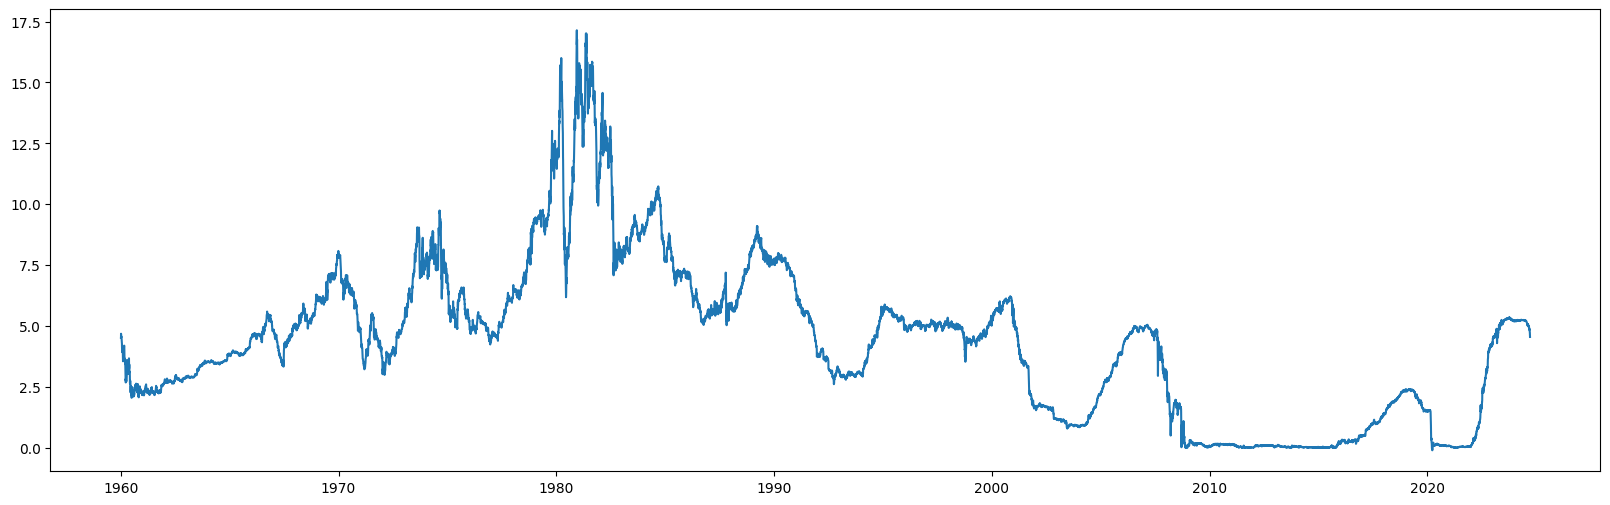

In [ ]:
plt.figure(figsize=(20,6))
plt.plot(data)

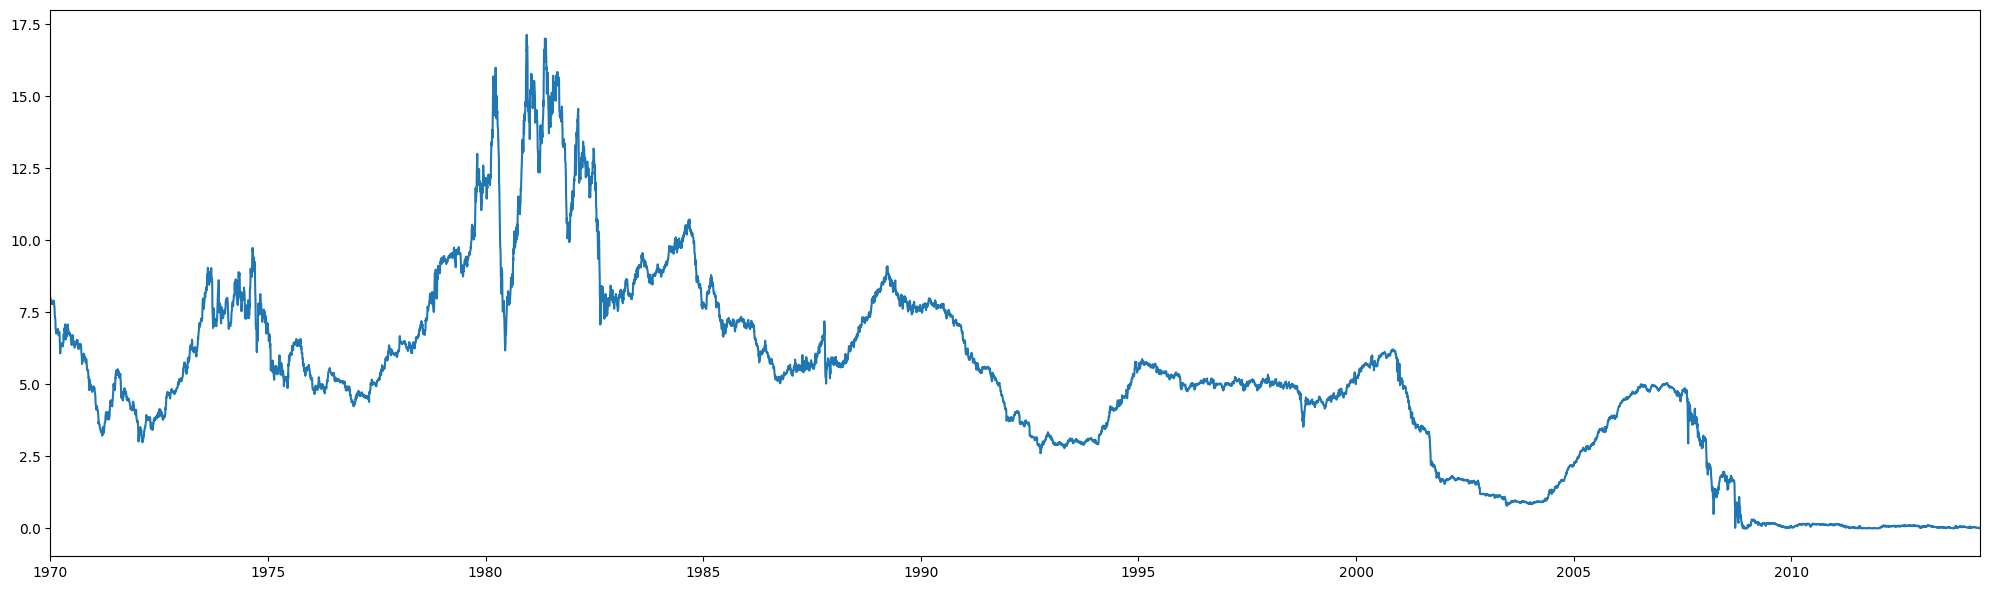

In [ ]:
#Plot of Time Series
from scipy.interpolate import interp1d
plt.figure(figsize=(20,6))
plt.plot(data)
plt.tight_layout()
plt.xlim([0,len(data)])
plt.show()

In [ ]:
data = np.asarray(data)
data.shape

(16194,)

In [ ]:
#Scale the Data to -1,1
scaler = MinMaxScaler(feature_range = (-1,1))
scaled_data = scaler.fit_transform(data.reshape(-1,1))
scaled_data.shape
scaled_data = np.squeeze(scaled_data)
scaled_data.shape

(16194,)

In [ ]:
scaled_data = np.transpose(scaled_data)

In [ ]:
# before you do the EMD, cut out the out of sample part so that the EMDs are not constructed with those future values and information contained within them

in_sample = scaled_data[:-1000]; out_sample = scaled_data[-1000:]

In [ ]:
print(in_sample.shape)

(15194,)


# EMD

De Yang et. al (2015), resumen:

La técnica de **descomposición modal empírica (EMD)** se utiliza para descomponer una señal no estacionaria en una serie de funciones modales intrínsecas (IMF). Esta capacidad hace que el HHT sea competitivo en el procesamiento de diversas señales compuestas. Con el HHT, las señales complejas pueden descomponerse en múltiples señales de una sola frecuencia, que luego pueden procesarse mediante la función modal intrínseca del EMD. *Después de que las señales no estacionarias han sido descompuestas en IMF a través de EMD, estas señales pueden obtenerse fácilmente mediante la transformada de Hilbert de cada función modal*. Al hacerlo, los investigadores pueden obtener la frecuencia y amplitud instantáneas de cada IMF. Con el espectro de Hilbert y el espectro marginal de Hilbert de las IMF, es posible obtener con precisión la distribución conjunta de la energía en función de la frecuencia y el tiempo, y además predecir si el equipo de IoT está en condiciones normales o no. En comparación con FFT y VT, HHT es un método de análisis tiempo-frecuencia fuertemente adaptativo.



In [ ]:
from pyhht.emd import EMD
from pyhht.visualization import plot_imfs

decomposer1 = EMD(in_sample,  maxiter = 10000)
imfs1 = decomposer1.decompose()
print("There are a total of %s IMFs" % len(imfs1))

There are a total of 12 IMFs


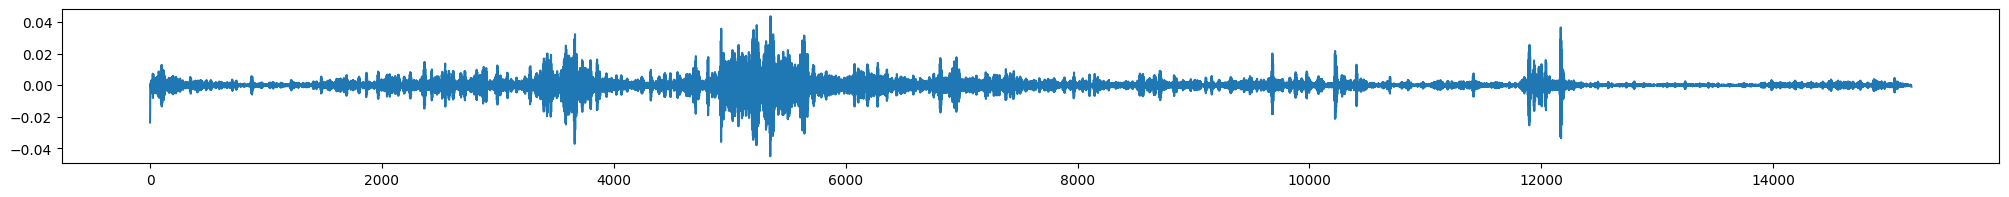

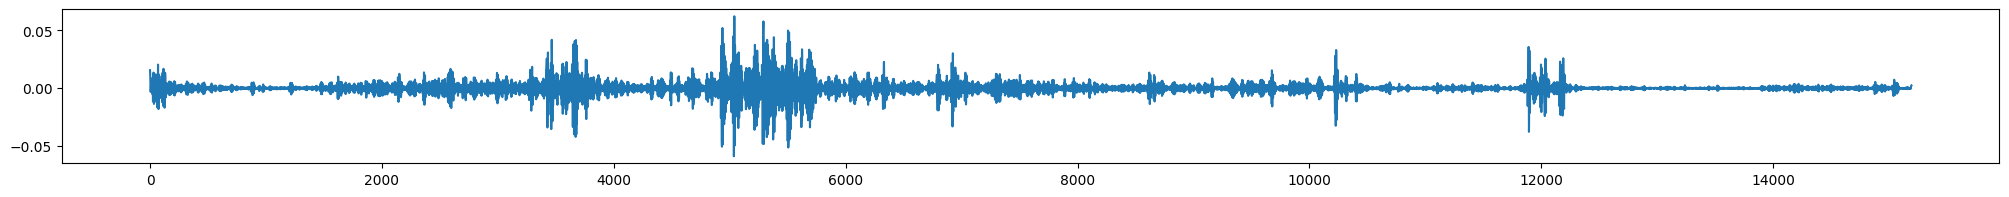

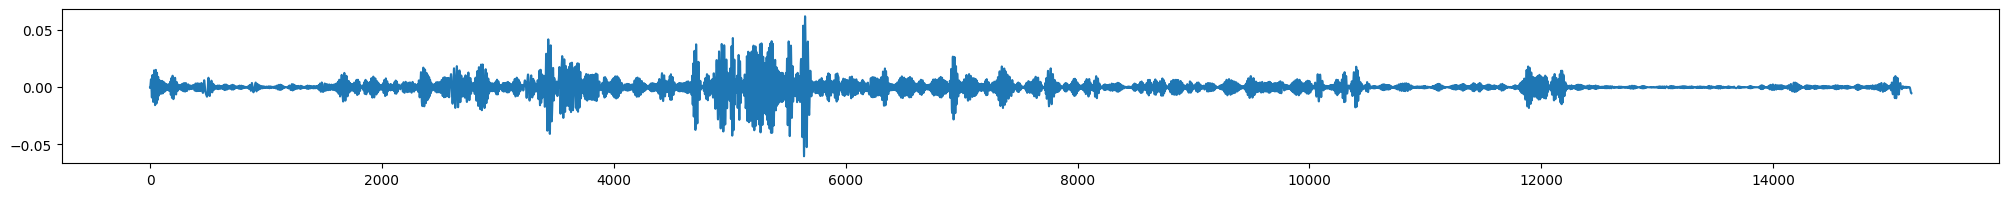

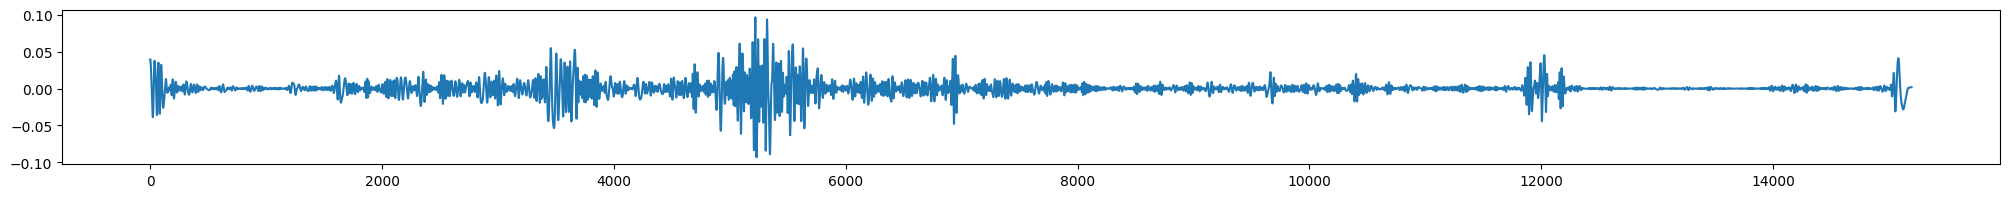

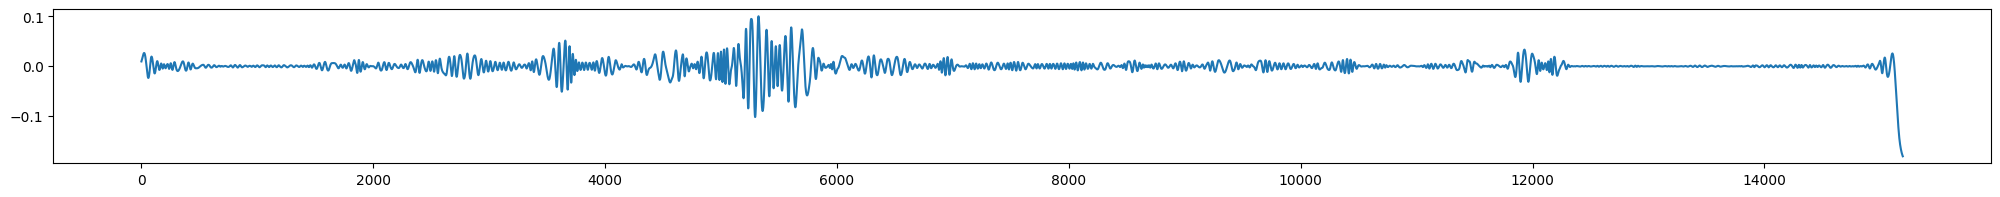

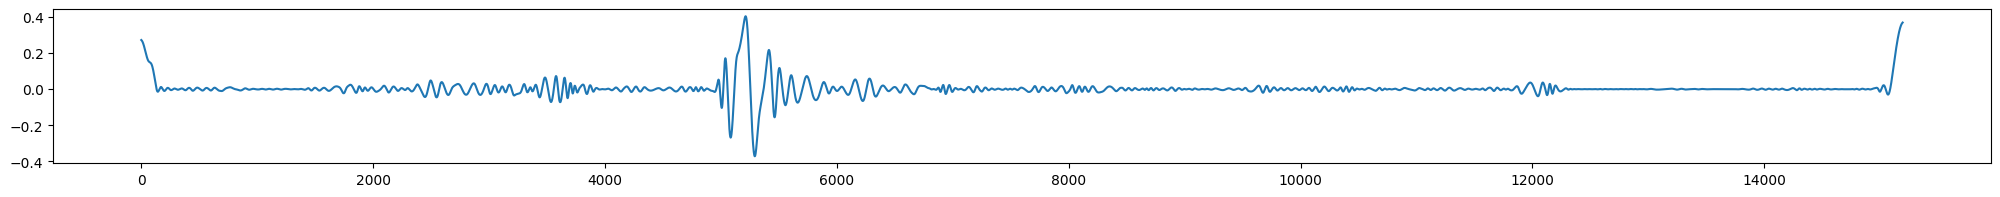

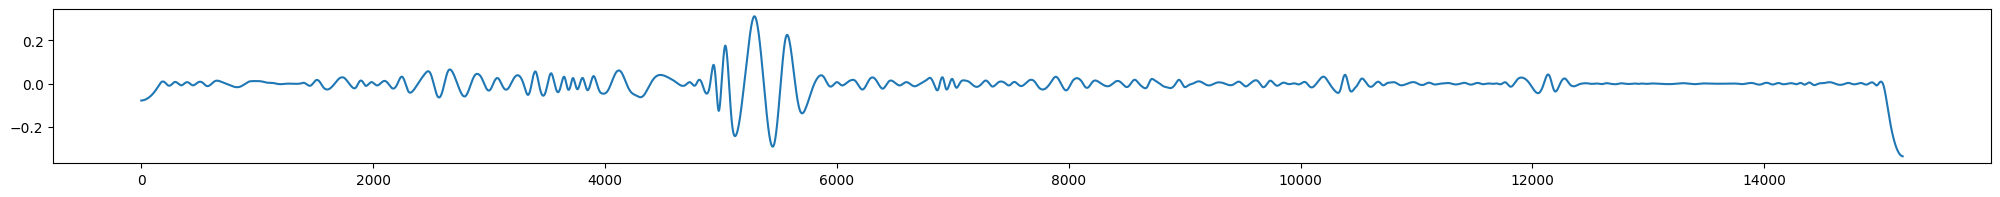

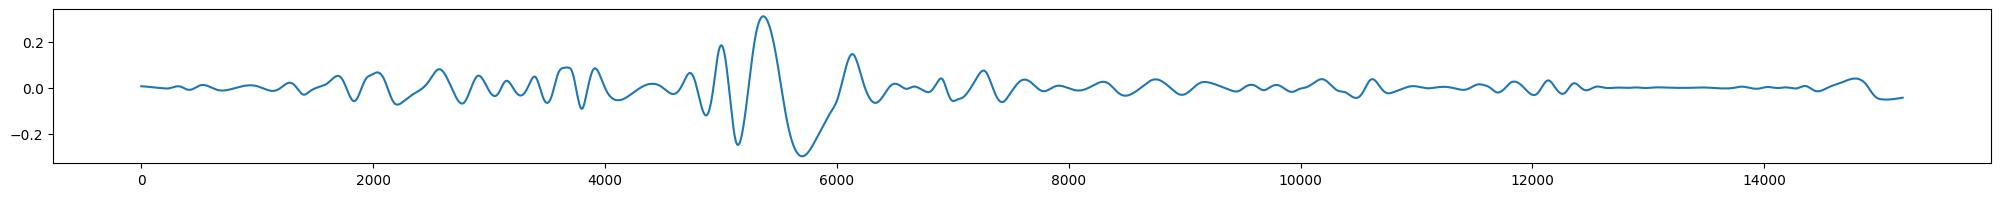

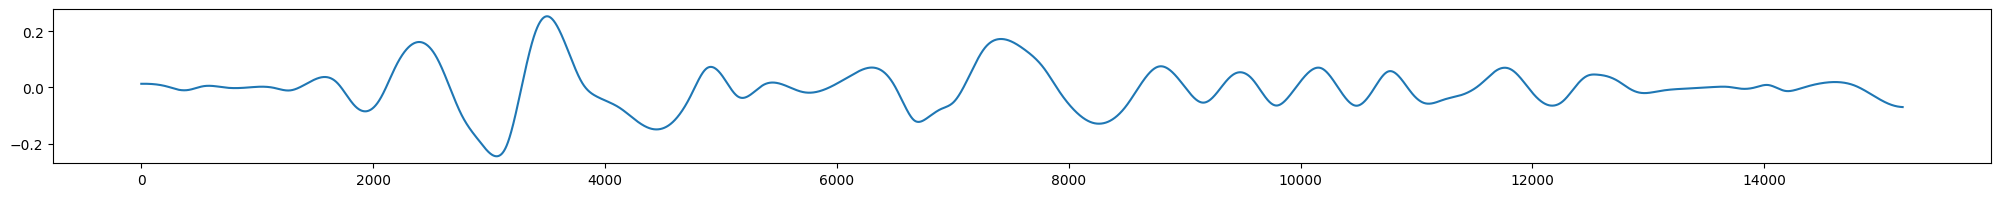

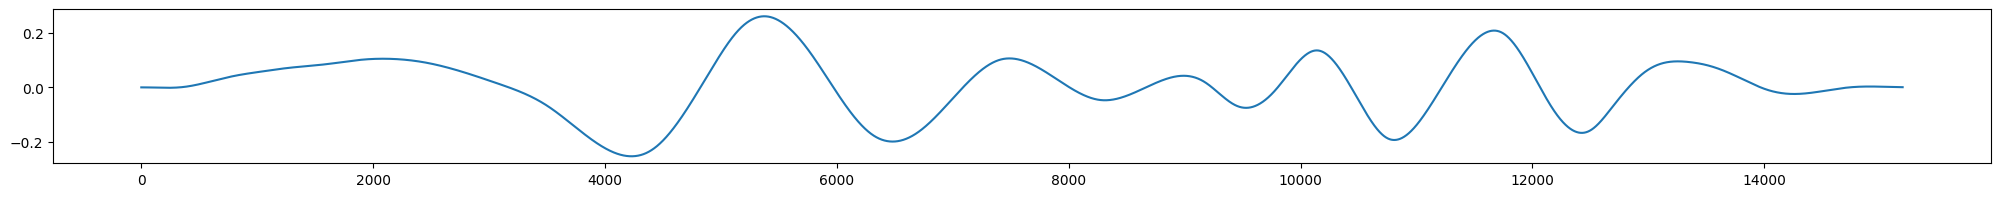

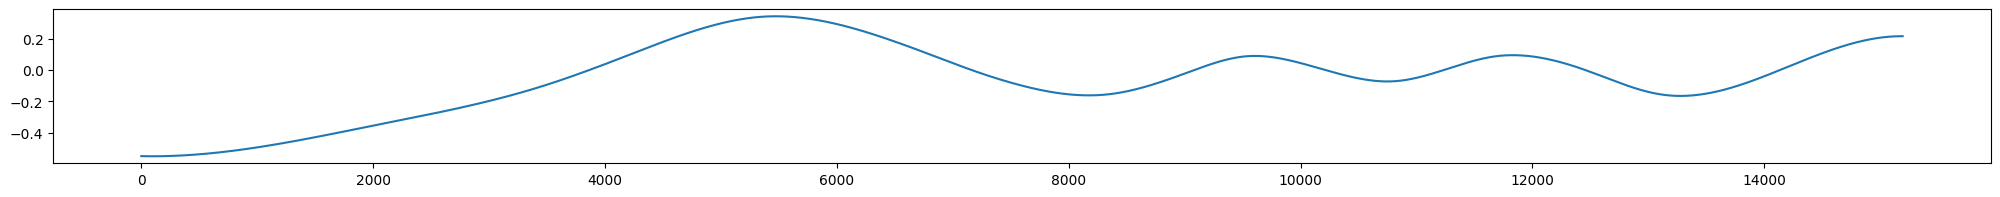

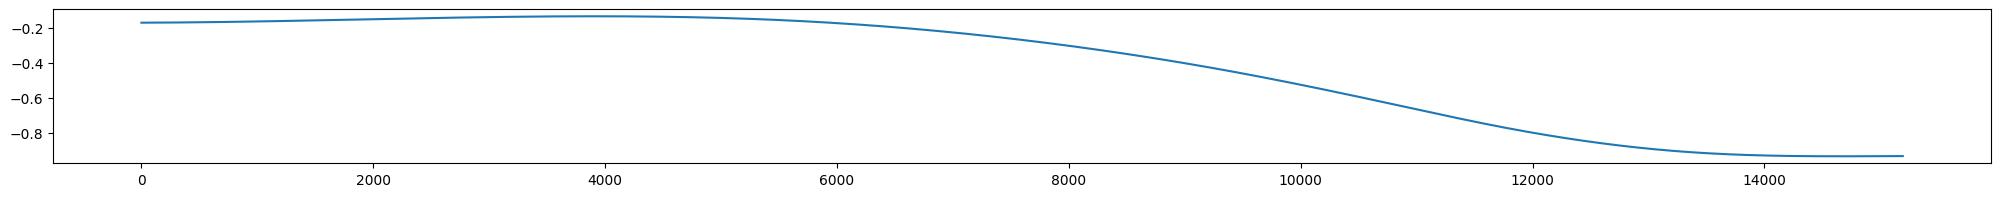

In [ ]:
#Plot the IMFs, from highest frequency to lowest. The last one should be a monotonic trend function. It is known as the residue,
#the irreducible trend left after the detrending of the EMD process.
for i in range(len(imfs1)):
  fig, ax = plt.subplots(figsize=(25,2))
  fig = plt.plot(imfs1[i])
  plt.show()

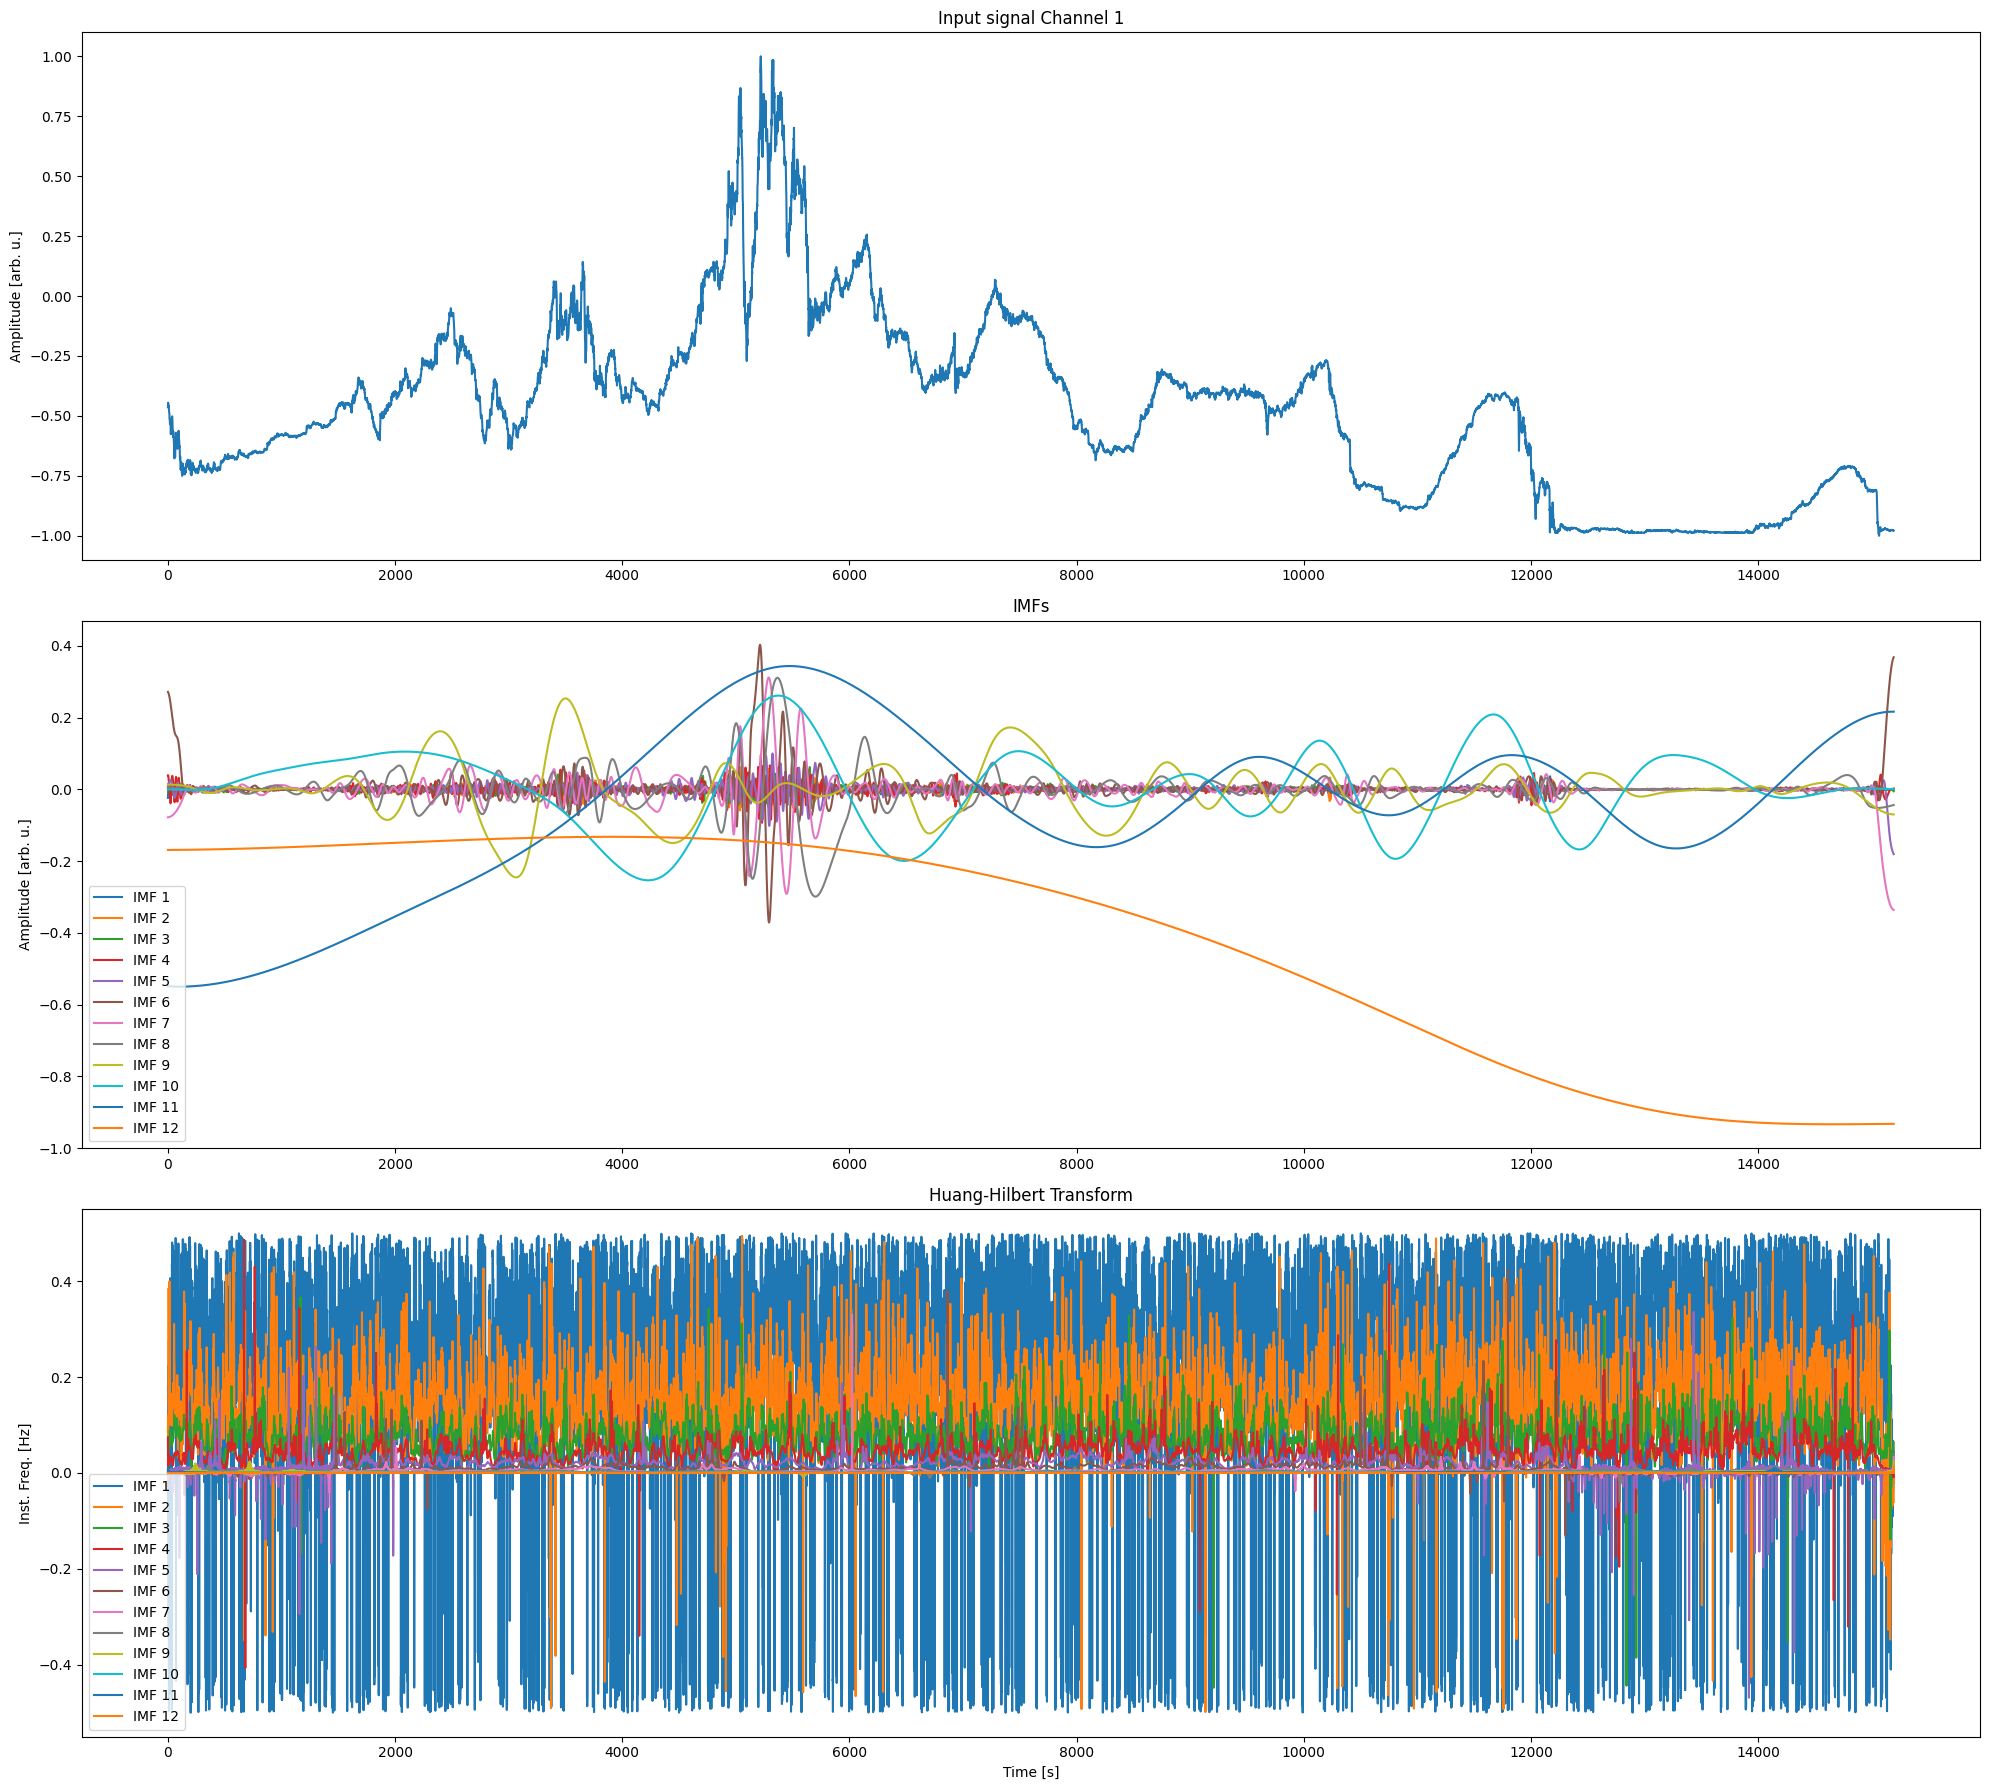

In [ ]:
import numpy as np
import pylab as plt
from scipy.signal import hilbert

#from PyEMD import EMD


def instant_phase(imfs):
    """Extract analytical signal through Hilbert Transform."""
    analytic_signal = hilbert(imfs)  # Apply Hilbert transform to each row
    phase = np.unwrap(np.angle(analytic_signal))  # Compute angle between img and real
    return phase

t = np.linspace(0,len(in_sample),len(in_sample))
dt = 1
# Extract instantaneous phases and frequencies using Hilbert transform
instant_phases = instant_phase(imfs1)
instant_freqs = np.diff(instant_phases)/(2*np.pi*dt)

# Create a figure consisting of 3 panels which from the top are the input signal, IMFs and instantaneous frequencies
fig, axes = plt.subplots(3, figsize=(20,18))

# The top panel shows the input signal
ax = axes[0]
ax.plot(t, in_sample)
ax.set_ylabel("Amplitude [arb. u.]")
ax.set_title("Input signal Channel 1")

# The middle panel shows all IMFs
ax = axes[1]
for num, imf in enumerate(imfs1):
    ax.plot(t, imf, label='IMF %s' %(num+1))

# Label the figure
ax.legend()
ax.set_ylabel("Amplitude [arb. u.]")
ax.set_title("IMFs")

# The bottom panel shows all instantaneous frequencies
ax = axes[2]
for num, instant_freq in enumerate(instant_freqs):
    ax.plot(t[:-1], instant_freq, label='IMF %s'%(num+1))

# Label the figure
ax.legend()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Inst. Freq. [Hz]")
ax.set_title("Huang-Hilbert Transform")

plt.tight_layout()
plt.savefig('hht_example', dpi=120)
plt.show()


# Creando Datasets


## Ejemplo de función "series_to_supervised"

In [ ]:
datito = np.array([0,1,2,3,4,5,6]).reshape(-1,1)

In [ ]:
cosa = series_to_supervised(datito, n_in=3, n_out=1, dropnan=True)
cosa

,var1(t-3),var1(t-2),var1(t-1),var1(t)
3,0.0,1.0,2.0,3
4,1.0,2.0,3.0,4
5,2.0,3.0,4.0,5
6,3.0,4.0,5.0,6


*Raw Data, using a certian number of lags; most of my experimentation has beeen with either 10 or 20.

In [ ]:
in_sample = in_sample.reshape(-1,1); print(in_sample.shape)

(15194, 1)


In [ ]:
lookback = 10
data_f = series_to_supervised(in_sample, n_in = lookback, n_out = 1, dropnan = True)

In [ ]:
print(data_f.shape)
data_f = np.asarray(data_f)
Xr = data_f[:,:-1]
Y = data_f[:,-1]
print(Xr.shape, Y.shape)

(15184, 11)
(15184, 10) (15184,)


# Usar las IMFs, que son series de tiempo de misma longitud a la serie original, se usan como características para la red convolucional.

In [ ]:
imfs1.shape

(12, 15194)

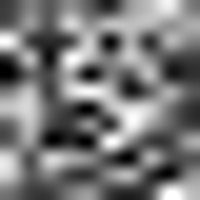

In [ ]:
from PIL import Image
img = Image.fromarray(imfs1[:,:10], 'L')
img.save('my.png')
img.resize((200,200))


In [ ]:
imfs1.shape
imfs1 = np.transpose(imfs1, (1,0)); imfs1.shape

(15194, 12)

In [ ]:
imf_df = series_to_supervised(imfs1, n_in = lookback, n_out = 1, dropnan = True)
imf_df = np.expand_dims(imf_df, axis = 1)
print(imf_df.shape)

(15184, 1, 132)


In [ ]:
series_to_supervised(imfs1, n_in = lookback, n_out = 1, dropnan = True)

,var1(t-10),var2(t-10),var3(t-10),var4(t-10),var5(t-10),var6(t-10),var7(t-10),var8(t-10),var9(t-10),var10(t-10),...,var3(t),var4(t),var5(t),var6(t),var7(t),var8(t),var9(t),var10(t),var11(t),var12(t)
10,-0.023603,0.015623,-0.000365,0.039503,0.009705,0.271924,-0.077890,0.006317,0.013119,0.000047,...,0.003736,0.014691,0.018383,0.262841,-0.077265,0.006001,0.013184,0.000057,-0.549280,-0.168885
11,-0.018388,0.013515,-0.000346,0.039697,0.010415,0.271372,-0.077851,0.006287,0.013127,0.000049,...,0.001648,0.010566,0.019313,0.261491,-0.077173,0.005967,0.013189,0.000057,-0.549298,-0.168883
12,0.000200,0.009943,0.000171,0.039103,0.011179,0.270742,-0.077807,0.006256,0.013135,0.000051,...,-0.000568,0.006365,0.020225,0.260062,-0.077076,0.005933,0.013193,0.000057,-0.549316,-0.168881
13,-0.000389,0.005012,0.001133,0.037753,0.011989,0.270033,-0.077758,0.006226,0.013142,0.000052,...,-0.003055,0.002040,0.021112,0.258552,-0.076974,0.005899,0.013197,0.000057,-0.549334,-0.168878
14,0.000657,-0.000030,0.002460,0.035704,0.012839,0.269246,-0.077703,0.006195,0.013149,0.000054,...,-0.005765,-0.002481,0.021964,0.256963,-0.076866,0.005865,0.013201,0.000056,-0.549351,-0.168876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15189,-0.000176,0.000082,-0.000132,0.001547,-0.168810,0.353439,-0.332376,-0.044653,-0.069477,0.000805,...,-0.004645,0.001770,-0.177763,0.365650,-0.335293,-0.043773,-0.069793,0.000736,0.216750,-0.932614
15190,-0.000082,-0.000180,-0.000365,0.001582,-0.169879,0.354993,-0.332775,-0.044566,-0.069514,0.000798,...,-0.004920,0.001794,-0.178469,0.366477,-0.335455,-0.043683,-0.069818,0.000730,0.216748,-0.932611
15191,0.000216,-0.000312,-0.000686,0.001611,-0.170907,0.356472,-0.333149,-0.044479,-0.069550,0.000791,...,-0.005118,0.001821,-0.179147,0.367237,-0.335593,-0.043594,-0.069842,0.000723,0.216744,-0.932608
15192,-0.000214,0.000032,-0.001088,0.001635,-0.171894,0.357876,-0.333500,-0.044392,-0.069585,0.000784,...,-0.005241,0.001851,-0.179799,0.367932,-0.335709,-0.043504,-0.069864,0.000717,0.216740,-0.932606


In [ ]:
imf_df = np.reshape(imf_df, (imf_df.shape[0], (lookback +1), imfs1.shape[-1]))

print(imf_df.shape)


(15184, 11, 12)


In [ ]:
targets = imf_df[:,-1,:]
print(targets.shape)

(15184, 12)


In [ ]:
print(Xr.shape)

(15184, 10)


In [ ]:
#so reshape everything properly
input_data = np.reshape(Xr, (targets.shape[0],1,lookback))
targets = np.reshape(targets,(targets.shape[0],1,targets.shape[1]))
print(input_data.shape, targets.shape)

(15184, 1, 10) (15184, 1, 12)


In [ ]:
#test Y values--completely out of sample. The calculation of the IMFs
#was not influenced by these values. No information contamination from future to past.

out_df = series_to_supervised(out_sample.reshape(-1,1), n_in = lookback, n_out = 1, dropnan = True)
print(out_df.shape); out_df = np.asarray(out_df)
testY = out_df[:,-1]
testX = out_df[:,:-1]

testX = np.expand_dims(testX, axis = 1)
print(testX.shape,testY.shape)

(990, 11)
(990, 1, 10) (990,)


# Autocorrelación parcial



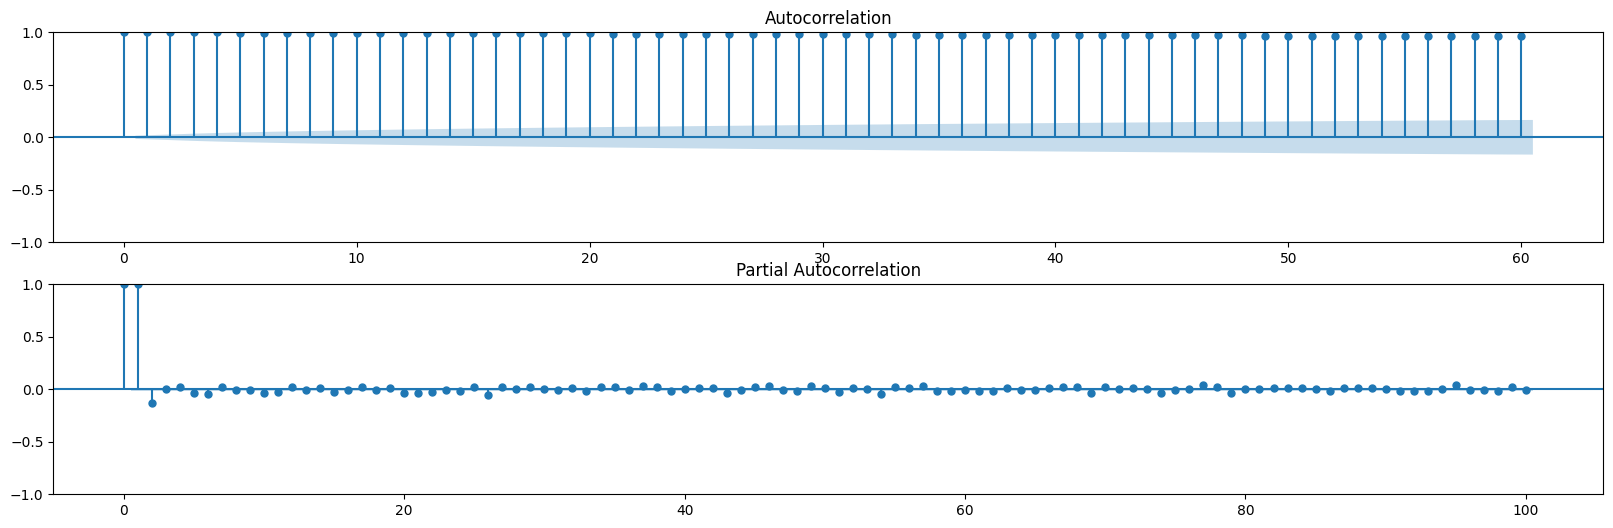

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

fig, axes = plt.subplots(2, figsize=(20,6))
fig1 = plot_acf(scaled_data,lags = 60, ax = axes[0])
fig2 = plot_pacf(scaled_data, lags = 100, ax = axes[1])
plt.show()

# Arquitectura de la red y entrenamiento del modelo

In [ ]:
from keras.layers import *#.advanced_activations import *
from keras.regularizers import l1, l2
from sklearn.metrics import r2_score
import keras.backend as K
from keras.layers import ConvLSTM2D
from keras.layers import LeakyReLU
from keras.optimizers import Adam

np.random.seed(2018) #inputs are (1, 20) and outputs are #(1 time step,17 features)

def convs(x, n, f, rate, bn = False):
  x = Conv1D(n, f, padding = "causal", dilation_rate = rate, activation="tanh")(x)
  if bn == False:
    x = x
  else:
    x = BatchNormalization()(x)
  return x


inputs = Input(shape = (1, lookback))

x = convs(x = inputs, n = 128, f = 3, rate = 2, bn = False)
y = convs(x = inputs, n = 128, f = 3, rate = 4, bn = False)
u = convs(x = inputs, n = 128, f = 3, rate = 8, bn = False)
v = convs(x = inputs, n = 128, f = 3, rate = 16, bn = False)

z = concatenate([inputs, x, y, u, v], axis = -1)
z = Activation("tanh")(z)
z = Dropout(0.3)(z)

predictions = Conv1D( targets.shape[-1], 3, padding = "causal", dilation_rate = 1)(z)



model = Model(inputs = inputs, outputs = predictions)
opt = Adam(learning_rate = 1e-3, clipnorm = 1.)
reduce_lr = ReduceLROnPlateau(monitor='loss', factor = 0.9, patience = 3, min_lr = 1e-5, verbose = 1)
checkpointer = ModelCheckpoint(filepath = "timeseries_weights.keras", verbose = 1, save_best_only = True)
early = EarlyStopping(monitor = 'loss', min_delta = 1e-4, patience = 10, verbose = 1)

model.compile(optimizer=opt, loss='mse', metrics = [])
model.summary()

history = model.fit(input_data, targets,
          epochs = 20,
          batch_size = 128,
          verbose = 1,
          #validation_data = (validX, validY),
          callbacks = [reduce_lr, early],
          shuffle = False)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 1, 10)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_25 (Conv1D)        │ (None, 1, 128)         │          3,968 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_26 (Conv1D)        │ (None, 1, 128)         │          3,968 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_27 (Conv1D)        │ (None, 1, 128)         │          3,968 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_28 (Conv1D)        │ (None, 1, 128)         │          3,968 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_5             │ (None, 1, 522)         │              0 │ input_layer_5[0][0],   │
│ (Concatenate)             │                        │                │ conv1d_25[0][0],       │
│                           │                        │                │ conv1d_26[0][0],       │
│                           │                        │                │ conv1d_27[0][0],       │
│                           │                        │                │ conv1d_28[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_5 (Activation) │ (None, 1, 522)         │              0 │ concatenate_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 1, 522)         │              0 │ activation_5[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_29 (Conv1D)        │ (None, 1, 12)          │         18,804 │ dropout_5[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 34,676 (135.45 KB)

 Trainable params: 34,676 (135.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0115 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0198 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0188 - learning_rate: 0.0010
Epoch 4/20
116/119 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0183
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0009000000427477062.
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0180 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0178 - learning_rate: 9.0000e-04
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0180 - learning_rate: 9.0000e-04
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0184 - learning_rate: 9.0000e-04
Epoch 8/20
116/119 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0189
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0008100000384729356.
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0186 - learning_rate

In [ ]:
preds = model.predict(testX, batch_size = 1)
summed = np.sum(preds, axis = -1); print(summed.shape)
test_preds = summed[:,0]
plt.plot(test_preds)

# R2 score

Ayuda a ver que tan bien replican las salidas del modelo a los datos originales.

In [ ]:
testY.shape

In [ ]:
np.set_printoptions(suppress=True)

In [ ]:
scaler.inverse_transform(test_preds.reshape(-1,1))

In [ ]:
scaler.inverse_transform(testY.reshape(-1,1))

In [ ]:
print("R2 Score: {}".format(r2_score(testY, test_preds)))

fig = plt.figure(figsize = (20,6))
fig = plt.plot(test_preds, label = "PREDICCION")
fig = plt.plot(testY, label = "REAL")
plt.xlim([0,990])
plt.legend()
plt.show()

plt.clf()
plt.cla()
plt.close()

In [ ]:
print("R2 Score: {}".format(r2_score(testY, test_preds)))

fig = plt.figure(figsize = (20,6))
fig = plt.plot(scaler.inverse_transform(test_preds.reshape(-1,1)), label = "PREDICCION")
fig = plt.plot(scaler.inverse_transform(testY.reshape(-1,1)), label = "REAL")
plt.xlim([0,990])
plt.legend()
plt.show()

plt.clf()
plt.cla()
plt.close()

# Referencias:

https://peijin.medium.com/time-series-forecasting-using-empirical-mode-decomposition-and-dilated-convolutional-networks-3-83992c3be324

https://github.com/3catz/deeplearning_timeseries/blob/master/IRX_Treasury_Time_Series_Forecasting_with_EMD_and_Fully_Convolutional_Neural_Networks.ipynb